In [554]:
# =========================
# 1. LIBRERÍAS
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

In [555]:
# =========================
# 2. CARGA DE DATOS
# =========================

encuestas = pd.read_csv("/Users/saraelbachouti/Desktop/UCV-Churn/data/raw/encuestas_texto.csv")
calidad = pd.read_csv("/Users/saraelbachouti/Desktop/UCV-Churn/data/raw/calidad_senal_zona_mensual.csv")
churn = pd.read_csv("/Users/saraelbachouti/Desktop/UCV-Churn/data/raw/churn_target.csv")

display(encuestas.head())
display(calidad.head())
display(churn.head())

,encuesta_id,fecha,zona_id,region,tipo_zona,puntuacion_general_1a5,nps_0a10,texto_libre,indice_calidad_global,incidencia_masiva,stress_calidad,flag_incongruente,sent_text_latente
0,E77700132,2023-01-01,Z04,Centro,suburbana,3,0,Desde hace meses no tengo cobertura dentro de ...,35.13,0,0.4981,0,-0.913
1,E77700023,2023-01-01,Z05,Este,urbana_premium,5,1,En las últimas semanas se corta en llamadas. e...,40.98,0,0.4146,1,-0.619
2,E77700582,2023-01-01,Z05,Este,urbana_premium,5,0,En mi experiencia la cobertura es mala. la vel...,40.98,0,0.4146,1,-0.574
3,E77700150,2023-01-01,Z09,Norte,urbana_premium,2,3,En mi experiencia se queda sin servicio. hay m...,41.35,0,0.4093,0,-1.000
4,E77700247,2023-01-01,Z09,Norte,urbana_premium,3,3,En mi experiencia hay cortes constantes. los d...,41.35,0,0.4093,0,-0.700


,fecha,zona_id,region,tipo_zona,poblacion_zona,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva
0,2023-01-01,Z01,Centro,rural,16625,82.46,4.03,56.17,30.61,3.01,18.51,0
1,2023-02-01,Z01,Centro,rural,16625,82.11,4.31,55.69,30.95,3.06,19.61,0
2,2023-03-01,Z01,Centro,rural,16625,82.19,4.56,55.45,31.05,2.96,16.99,0
3,2023-04-01,Z01,Centro,rural,16625,81.90,4.69,55.72,30.43,3.00,20.81,0
4,2023-05-01,Z01,Centro,rural,16625,81.86,5.38,55.38,30.47,3.01,18.61,0


,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0


In [609]:
# =========================
# 3. REVISAR COLUMNAS
# =========================

print(encuestas.columns)
print(calidad.columns)
print(churn.columns)

Index(['encuesta_id', 'fecha', 'zona_id', 'region', 'tipo_zona',
       'puntuacion_general_1a5', 'nps_0a10', 'texto_libre',
       'indice_calidad_global', 'incidencia_masiva', 'stress_calidad',
       'flag_incongruente', 'sent_text_latente', 'texto_limpio',
       'sentimiento_score', 'sentimiento', 'cluster', 'mes'],
      dtype='str')
Index(['fecha', 'zona_id', 'region', 'tipo_zona', 'poblacion_zona',
       'cobertura_4g_pct', 'cobertura_5g_pct', 'latencia_ms',
       'velocidad_media_mbps', 'tasa_cortes_pct', 'indice_calidad_global',
       'incidencia_masiva'],
      dtype='str')
Index(['cliente_id', 'fecha', 'churn', 'mes'], dtype='str')


In [610]:
# =========================
# 4. NOMBRES DE COLUMNAS
# =========================

texto_col = "texto_libre"
puntuacion_col = "puntuacion_general_1a5"
zona_col = "zona_id"
fecha_col = "fecha"

In [611]:
# =========================
# 5. VER NULOS Y DUPLICADOS
# =========================

print(encuestas.isnull().sum())

print("Duplicados:")
print(encuestas.duplicated().sum())

encuesta_id               0
fecha                     0
zona_id                   0
region                    0
tipo_zona                 0
puntuacion_general_1a5    0
nps_0a10                  0
texto_libre               0
indice_calidad_global     0
incidencia_masiva         0
stress_calidad            0
flag_incongruente         0
sent_text_latente         0
texto_limpio              0
sentimiento_score         0
sentimiento               0
cluster                   0
mes                       0
dtype: int64
Duplicados:
0


In [612]:
# =========================
# 6. LIMPIEZA SIMPLE
# =========================

encuestas = encuestas.drop_duplicates()

encuestas[texto_col] = encuestas[texto_col].fillna("")

encuestas[puntuacion_col] = encuestas[puntuacion_col].fillna(
    encuestas[puntuacion_col].median()
)

In [560]:
# =========================
# 6.1 ELIMINAR PUNTUACIONES INCORRECTAS
# =========================

encuestas = encuestas[
    (encuestas["puntuacion_general_1a5"] >= 1) &
    (encuestas["puntuacion_general_1a5"] <= 5)
]

In [561]:
# =========================
# 7. LIMPIAR TEXTO
# =========================

# pasar a minúsculas
encuestas["texto_limpio"] = encuestas[texto_col].str.lower()

# quitar símbolos y números
encuestas["texto_limpio"] = encuestas["texto_limpio"].str.replace(
    r"[^a-záéíóúñü\s]",
    "",
    regex=True
)

display(encuestas[[texto_col, "texto_limpio"]].head())

,texto_libre,texto_limpio
0,Desde hace meses no tengo cobertura dentro de ...,desde hace meses no tengo cobertura dentro de ...
1,En las últimas semanas se corta en llamadas. e...,en las últimas semanas se corta en llamadas el...
2,En mi experiencia la cobertura es mala. la vel...,en mi experiencia la cobertura es mala la velo...
3,En mi experiencia se queda sin servicio. hay m...,en mi experiencia se queda sin servicio hay mu...
4,En mi experiencia hay cortes constantes. los d...,en mi experiencia hay cortes constantes los da...


In [562]:
# =========================
# 8. PALABRAS MÁS FRECUENTES
# =========================

palabras = []

for texto in encuestas["texto_limpio"]:
    
    texto = texto.split()
    
    for palabra in texto:
        
        palabras.append(palabra)

In [563]:
frecuencias = Counter(palabras)

print(frecuencias.most_common(20))

[('en', 856), ('no', 820), ('la', 740), ('es', 547), ('se', 539), ('mi', 419), ('lo', 417), ('cobertura', 395), ('me', 393), ('que', 370), ('por', 300), ('sin', 293), ('zona', 274), ('nota', 243), ('hay', 238), ('de', 185), ('los', 170), ('más', 153), ('atención', 149), ('general', 149)]


In [564]:
# convertir a dataframe

df_palabras = pd.DataFrame(
    frecuencias.most_common(20),
    columns=["palabra", "frecuencia"]
)

display(df_palabras)

,palabra,frecuencia
0,en,856
1,no,820
2,la,740
3,es,547
4,se,539
5,mi,419
6,lo,417
7,cobertura,395
8,me,393
9,que,370


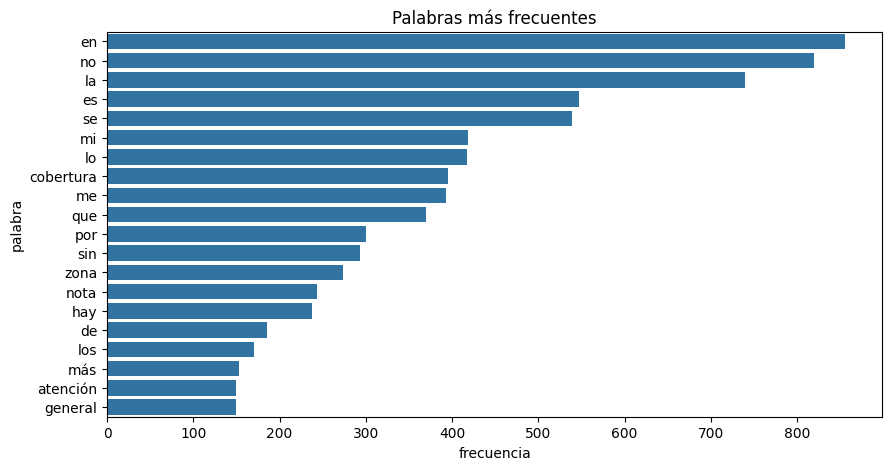

In [565]:
# gráfico

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_palabras,
    x="frecuencia",
    y="palabra"
)

plt.title("Palabras más frecuentes")
plt.show()

In [566]:
# =========================
# 9. SENTIMIENTO SIMPLE
# =========================

positivas = [
    "bueno",
    "excelente",
    "rápido",
    "perfecto",
    "bien"
]

negativas = [
    "malo",
    "problema",
    "lento",
    "fallo",
    "cortes",
    "mal"
]

In [567]:
# función sentimiento

def sentimiento(texto):
    
    puntos = 0
    
    palabras = texto.split()
    
    for palabra in palabras:
        
        if palabra in positivas:
            puntos += 1
            
        elif palabra in negativas:
            puntos -= 1
            
    return puntos

In [568]:
# aplicar sentimiento

encuestas["sentimiento_score"] = encuestas["texto_limpio"].apply(sentimiento)

In [569]:
# clasificar sentimiento

def clasificar(score):
    
    if score > 0:
        return "positivo"
    
    elif score < 0:
        return "negativo"
    
    else:
        return "neutral"

In [570]:
encuestas["sentimiento"] = encuestas["sentimiento_score"].apply(clasificar)

In [571]:
encuestas["sentimiento"].value_counts()

sentimiento
neutral     761
positivo    125
negativo    100
Name: count, dtype: int64

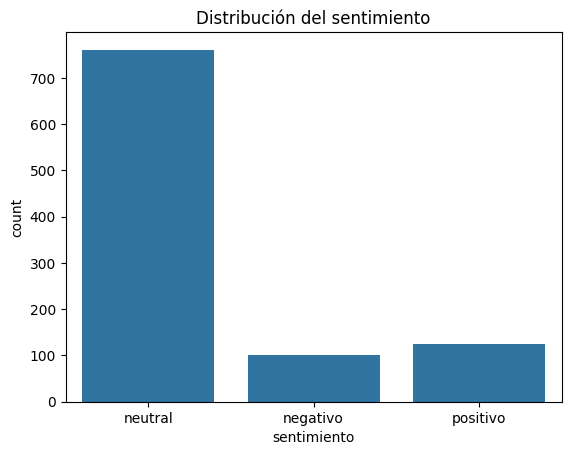

In [572]:
# gráfico sentimiento

sns.countplot(
    data=encuestas,
    x="sentimiento"
)

plt.title("Distribución del sentimiento")
plt.show()

In [573]:
# =========================
# 10. PUNTUACIÓN VS SENTIMIENTO
# =========================

encuestas.groupby("sentimiento")[puntuacion_col].mean()

sentimiento
negativo    3.150000
neutral     3.231275
positivo    3.312000
Name: puntuacion_general_1a5, dtype: float64

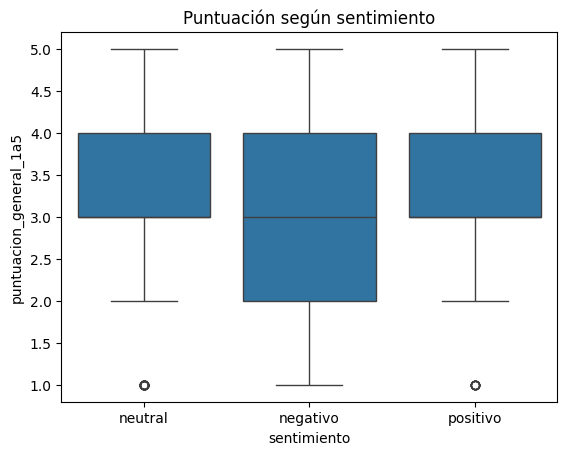

In [574]:
sns.boxplot(
    data=encuestas,
    x="sentimiento",
    y=puntuacion_col
)

plt.title("Puntuación según sentimiento")
plt.show()

In [575]:
# =========================
# 11. INCOHERENCIAS
# =========================

# puntuación alta
nota_alta = encuestas[puntuacion_col] >= 4

# sentimiento negativo
texto_negativo = encuestas["sentimiento"] == "negativo"

# unir condiciones
incoherencias = encuestas[nota_alta & texto_negativo]

In [576]:
# mostrar resultados

incoherencias[[
    "encuesta_id",
    "texto_libre",
    "puntuacion_general_1a5",
    "sentimiento"
]].head()

,encuesta_id,texto_libre,puntuacion_general_1a5,sentimiento
13,E77700137,En mi zona hay cortes constantes. los datos va...,4,negativo
43,E77700517,Este mes hay cortes constantes. el 5G ni se no...,4,negativo
52,E77700106,En mi zona hay cortes constantes. los datos va...,5,negativo
183,E77700077,En general hay cortes constantes. se nota cong...,5,negativo
265,E77700604,Este mes hay cortes constantes. el 5G ni se no...,5,negativo


In [577]:
print("Número de incoherencias:", len(incoherencias))

Número de incoherencias: 37


In [578]:
# =========================
# 12. TF-IDF
# =========================

tfidf = TfidfVectorizer(max_features=20)

X_tfidf = tfidf.fit_transform(encuestas["texto_limpio"])

In [579]:
# palabras importantes

palabras_tfidf = tfidf.get_feature_names_out()

print(palabras_tfidf)

['atención' 'cobertura' 'de' 'en' 'es' 'general' 'hay' 'la' 'lo' 'los'
 'me' 'mi' 'más' 'no' 'nota' 'por' 'que' 'se' 'sin' 'zona']


In [580]:
# =========================
# 13. CLUSTERING DE TEXTOS
# =========================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

encuestas["cluster"] = kmeans.fit_predict(X_tfidf)

In [581]:
encuestas["cluster"].value_counts()

cluster
1    342
0    325
2    319
Name: count, dtype: int64

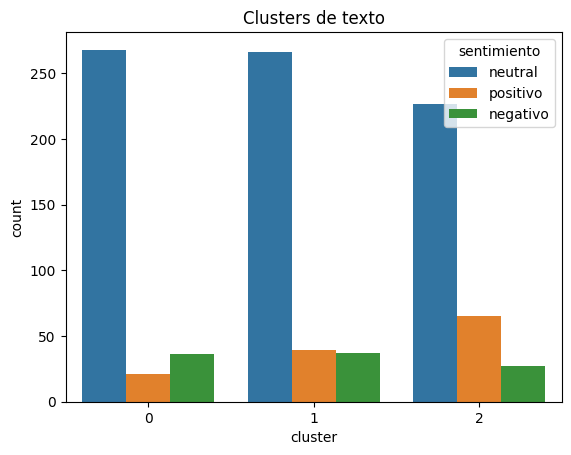

cluster
0   -0.043077
1    0.014620
2    0.137931
Name: sentimiento_score, dtype: float64
cluster
0    3.166154
1    3.254386
2    3.278997
Name: puntuacion_general_1a5, dtype: float64


In [616]:
sns.countplot(
    data=encuestas,
    x="cluster",
    hue="sentimiento"
)

plt.title("Clusters de texto")
plt.show()


# ==================================================
# SENTIMIENTO MEDIO POR CLUSTER
# ==================================================

print(
    encuestas.groupby("cluster")["sentimiento_score"]
    .mean()
)

# ==================================================
# PUNTUACIÓN MEDIA POR CLUSTER
# ==================================================

print(
    encuestas.groupby("cluster")[puntuacion_col]
    .mean()
)

In [584]:
# =========================
# 14. PREPARAR FECHAS
# =========================

encuestas["fecha"] = pd.to_datetime(
    encuestas["fecha"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

churn["fecha"] = pd.to_datetime(
    churn["fecha"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

# crear columna mes
encuestas["mes"] = encuestas["fecha"].dt.to_period("M").astype(str)

churn["mes"] = churn["fecha"].dt.to_period("M").astype(str)

In [585]:
# =========================
# 15. CHURN POR MES
# =========================

churn_mes = churn.groupby("mes")["churn"].mean().reset_index()

display(churn_mes.head())

,mes,churn
0,2023-01,0.006707
1,2024-01,0.006655
2,2025-01,0.005156


In [586]:
# =========================
# 16. SENTIMIENTO POR ZONA Y MES
# =========================

sentimiento_zona_mes = encuestas.groupby(
    [zona_col, "mes"]
).agg(
    sentimiento_medio=("sentimiento_score", "mean"),
    puntuacion_media=(puntuacion_col, "mean")
).reset_index()

In [587]:
display(sentimiento_zona_mes.head())

,zona_id,mes,sentimiento_medio,puntuacion_media
0,Z01,2023-01,0.000000,2.428571
1,Z01,2024-01,0.400000,2.800000
2,Z01,2025-01,0.000000,3.666667
3,Z02,2023-01,-0.142857,3.142857
4,Z02,2024-01,0.000000,3.307692


In [588]:

# =========================
# 17. UNIR CON CHURN
# =========================

# Limpiar columna mes
sentimiento_zona_mes["mes"] = sentimiento_zona_mes["mes"].astype(str).str.strip()

churn_mes["mes"] = churn_mes["mes"].astype(str).str.strip()

# Merge
df_final = sentimiento_zona_mes.merge(
    churn_mes,
    on="mes",
    how="left"
)

# Revisar nulos
print(df_final["churn"].isnull().sum())

14


In [589]:
display(df_final.head())

,zona_id,mes,sentimiento_medio,puntuacion_media,churn
0,Z01,2023-01,0.000000,2.428571,0.006707
1,Z01,2024-01,0.400000,2.800000,0.006655
2,Z01,2025-01,0.000000,3.666667,0.005156
3,Z02,2023-01,-0.142857,3.142857,0.006707
4,Z02,2024-01,0.000000,3.307692,0.006655


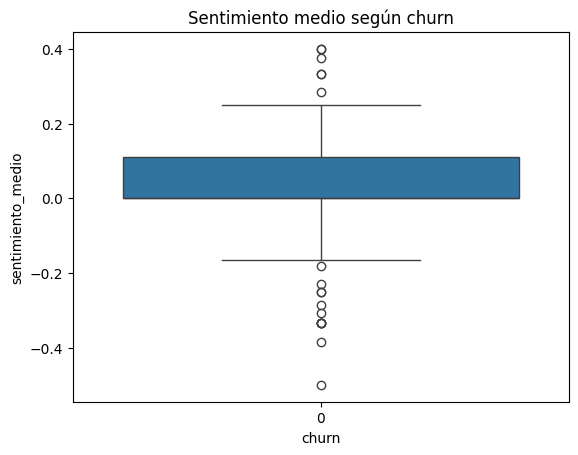

churn
0    0.011512
Name: sentimiento_medio, dtype: float64


In [613]:
# churn según sentimiento medio

sns.boxplot(
    data=df_final,
    x="churn",
    y="sentimiento_medio"
)

plt.title("Sentimiento medio según churn")

plt.show()

print(
    df_final.groupby("churn")["sentimiento_medio"]
    .mean()
)

In [591]:
# correlación

df_final[[
    "sentimiento_medio",
    "puntuacion_media",
    "churn"
]].corr()

,sentimiento_medio,puntuacion_media,churn
sentimiento_medio,1.000000,0.218652,-0.059773
puntuacion_media,0.218652,1.000000,-0.174418
churn,-0.059773,-0.174418,1.000000


## Hipótesis

1. Las zonas con textos más negativos presentan más churn.

2. El texto libre aporta información distinta a la puntuación numérica.

3. Existen incoherencias entre la puntuación y el tono del comentario.

4. Las palabras relacionadas con problemas técnicos aparecen con más frecuencia en clientes insatisfechos.

5. El sentimiento medio puede relacionarse con el churn.

## Conclusión final

El análisis de texto permite comprender mejor la percepción de los clientes. A través del sentimiento textual, las palabras frecuentes y el clustering de comentarios, se identifican patrones relacionados con la satisfacción y el churn.

Además, el texto libre aporta información adicional que no siempre aparece en la puntuación numérica de la encuesta.

In [592]:
df_final[df_final["churn"].isnull()]

,zona_id,mes,sentimiento_medio,puntuacion_media,churn
15,Z05,2025-12,0.0,4.0,NaN
18,Z06,2024-04,0.0,3.0,NaN
33,Z11,2023-11,0.0,2.0,NaN
35,Z11,2024-04,0.0,2.0,NaN
45,Z14,2025-07,0.0,3.0,NaN
47,Z15,2023-04,0.0,3.0,NaN
48,Z15,2023-07,0.0,2.0,NaN
56,Z17,2024-11,0.0,3.0,NaN
60,Z18,2024-08,0.0,4.0,NaN
65,Z19,2025-04,1.0,4.0,NaN


In [593]:
# Ver nulos en churn
print(df_final["churn"].isnull().sum())

# Eliminar filas con churn nulo
df_final = df_final.dropna(subset=["churn"])

# Convertir churn a entero
df_final["churn"] = df_final["churn"].astype(int)

# Comprobar otra vez
print("\nNulos en churn:")
print(df_final["churn"].isnull().sum())

print("\nNuevo shape:")
print(df_final.shape)

14

Nulos en churn:
0

Nuevo shape:
(89, 5)


In [594]:
# ============================================================
# QUALITY CHECK — DATASET ENCUESTAS
# ============================================================

print("="*60)
print("QUALITY CHECK - ENCUESTAS")
print("="*60)

print("\nSHAPE:")
print(encuestas.shape)

print("\nTOTAL NULOS:")
print(encuestas.isnull().sum().sum())

print("\nNULOS POR COLUMNA:")
print(encuestas.isnull().sum())

print("\nDUPLICADOS:")
print(encuestas.duplicated().sum())

print("\nTIPOS DE DATOS:")
print(encuestas.dtypes)

print("\nRANGO DE FECHAS:")
if "fecha" in encuestas.columns:
    print(encuestas["fecha"].min())
    print(encuestas["fecha"].max())

print("\nVALORES NEGATIVOS:")
negativos = {}

for col in encuestas.select_dtypes(include=["int64", "float64"]).columns:
    n_neg = (encuestas[col] < 0).sum()
    
    if n_neg > 0:
        negativos[col] = n_neg

if len(negativos) == 0:
    print("No hay valores negativos")
else:
    print(negativos)

print("\nCHECK FINAL:")
if (
    encuestas.isnull().sum().sum() == 0 and
    encuestas.duplicated().sum() == 0
):
    print("Dataset ENCUESTAS limpio")
else:
    print("Dataset ENCUESTAS todavía tiene problemas")

QUALITY CHECK - ENCUESTAS

SHAPE:
(986, 18)

TOTAL NULOS:
0

NULOS POR COLUMNA:
encuesta_id               0
fecha                     0
zona_id                   0
region                    0
tipo_zona                 0
puntuacion_general_1a5    0
nps_0a10                  0
texto_libre               0
indice_calidad_global     0
incidencia_masiva         0
stress_calidad            0
flag_incongruente         0
sent_text_latente         0
texto_limpio              0
sentimiento_score         0
sentimiento               0
cluster                   0
mes                       0
dtype: int64

DUPLICADOS:
0

TIPOS DE DATOS:
encuesta_id                          str
fecha                     datetime64[us]
zona_id                              str
region                               str
tipo_zona                            str
puntuacion_general_1a5             int64
nps_0a10                           int64
texto_libre                          str
indice_calidad_global            float64
in

In [595]:
# ============================================================
# QUALITY CHECK — DATASET CALIDAD
# ============================================================

print("="*60)
print("QUALITY CHECK - CALIDAD")
print("="*60)

print("\nSHAPE:")
print(calidad.shape)

print("\nTOTAL NULOS:")
print(calidad.isnull().sum().sum())

print("\nNULOS POR COLUMNA:")
print(calidad.isnull().sum())

print("\nDUPLICADOS:")
print(calidad.duplicated().sum())

print("\nTIPOS DE DATOS:")
print(calidad.dtypes)

print("\nRANGO DE FECHAS:")
if "fecha" in calidad.columns:
    print(calidad["fecha"].min())
    print(calidad["fecha"].max())

print("\nVALORES NEGATIVOS:")
negativos = {}

for col in calidad.select_dtypes(include=["int64", "float64"]).columns:
    n_neg = (calidad[col] < 0).sum()
    
    if n_neg > 0:
        negativos[col] = n_neg

if len(negativos) == 0:
    print("No hay valores negativos")
else:
    print(negativos)

print("\nCHECK FINAL:")
if (
    calidad.isnull().sum().sum() == 0 and
    calidad.duplicated().sum() == 0
):
    print("Dataset CALIDAD limpio")
else:
    print("Dataset CALIDAD todavía tiene problemas")

QUALITY CHECK - CALIDAD

SHAPE:
(1096, 12)

TOTAL NULOS:
97

NULOS POR COLUMNA:
fecha                     0
zona_id                   0
region                    0
tipo_zona                 0
poblacion_zona            0
cobertura_4g_pct         32
cobertura_5g_pct         32
latencia_ms              33
velocidad_media_mbps      0
tasa_cortes_pct           0
indice_calidad_global     0
incidencia_masiva         0
dtype: int64

DUPLICADOS:
16

TIPOS DE DATOS:
fecha                        str
zona_id                      str
region                       str
tipo_zona                    str
poblacion_zona             int64
cobertura_4g_pct         float64
cobertura_5g_pct         float64
latencia_ms              float64
velocidad_media_mbps     float64
tasa_cortes_pct          float64
indice_calidad_global    float64
incidencia_masiva          int64
dtype: object

RANGO DE FECHAS:
01/01/2023
2025-12-01

VALORES NEGATIVOS:
{'velocidad_media_mbps': np.int64(16)}

CHECK FINAL:
Dataset CALIDAD

In [596]:
# ============================================================
# LIMPIEZA DE NULOS EN CALIDAD
# ============================================================

calidad["cobertura_4g_pct"] = calidad["cobertura_4g_pct"].fillna(
    calidad["cobertura_4g_pct"].median()
)

calidad["cobertura_5g_pct"] = calidad["cobertura_5g_pct"].fillna(
    calidad["cobertura_5g_pct"].median()
)

calidad["latencia_ms"] = calidad["latencia_ms"].fillna(
    calidad["latencia_ms"].median()
)

In [597]:
# ============================================================
# ARREGLAR VELOCIDADES NEGATIVAS
# ============================================================

calidad.loc[
    calidad["velocidad_media_mbps"] < 0,
    "velocidad_media_mbps"
] = None

calidad["velocidad_media_mbps"] = calidad[
    "velocidad_media_mbps"
].fillna(
    calidad["velocidad_media_mbps"].median()
)

In [598]:
# ============================================================
# ELIMINAR DUPLICADOS EN CALIDAD
# ============================================================

print("Duplicados antes:")
print(calidad.duplicated().sum())

# eliminar duplicados
calidad = calidad.drop_duplicates()

print("\nDuplicados después:")
print(calidad.duplicated().sum())

Duplicados antes:
16

Duplicados después:
0


In [599]:
# =====================================================
# ARREGLAR CALIDAD_LIMPIA SIN PERDER TANTAS FILAS
# =====================================================

# 1. Quitar duplicados exactos
calidad_limpia = calidad_limpia.drop_duplicates()

# 2. Rellenar nulls reales con la mediana por zona
cols_reales = [
    "cobertura_4g_pct",
    "cobertura_5g_pct",
    "latencia_ms"
]

for col in cols_reales:
    calidad_limpia[col] = calidad_limpia.groupby("zona_id")[col].transform(
        lambda x: x.fillna(x.median())
    )

# 3. Si alguna zona completa no tenía datos, rellenar con mediana global
for col in cols_reales:
    calidad_limpia[col] = calidad_limpia[col].fillna(calidad_limpia[col].median())

# 4. Ordenar por zona y fecha
calidad_limpia["fecha"] = pd.to_datetime(calidad_limpia["fecha"], errors="coerce")

calidad_limpia = calidad_limpia.sort_values(["zona_id", "fecha"])

# 5. Recalcular lag y rolling
calidad_limpia["calidad_mes_anterior"] = (
    calidad_limpia.groupby("zona_id")["indice_calidad_global"].shift(1)
)

calidad_limpia["calidad_media_3_meses"] = (
    calidad_limpia.groupby("zona_id")["indice_calidad_global"]
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# 6. Rellenar el primer mes sin mes anterior con la calidad actual
calidad_limpia["calidad_mes_anterior"] = calidad_limpia["calidad_mes_anterior"].fillna(
    calidad_limpia["indice_calidad_global"]
)

# =====================================================
# CHECK FINAL
# =====================================================

print("SHAPE FINAL:")
print(calidad_limpia.shape)

print("\nTOTAL NULLS:")
print(calidad_limpia.isnull().sum().sum())

print("\nNULLS POR COLUMNA:")
print(calidad_limpia.isnull().sum())

print("\nDUPLICADOS:")
print(calidad_limpia.duplicated().sum())

if calidad_limpia.isnull().sum().sum() == 0 and calidad_limpia.duplicated().sum() == 0:
    print("\n✅ CALIDAD_LIMPIA ARREGLADO")
else:
    print("\n❌ AÚN HAY PROBLEMAS")

SHAPE FINAL:
(1080, 14)

TOTAL NULLS:
0

NULLS POR COLUMNA:
zona_id                  0
fecha                    0
region                   0
tipo_zona                0
poblacion_zona           0
cobertura_4g_pct         0
cobertura_5g_pct         0
latencia_ms              0
velocidad_media_mbps     0
tasa_cortes_pct          0
indice_calidad_global    0
incidencia_masiva        0
calidad_mes_anterior     0
calidad_media_3_meses    0
dtype: int64

DUPLICADOS:
0

✅ CALIDAD_LIMPIA ARREGLADO


In [600]:
import pandas as pd

calidad_limpia = pd.read_csv("data/processed/calidad_limpia.csv")

print(calidad_limpia.shape)

(1080, 14)


In [603]:
encuestas_limpio = encuestas.copy()

In [605]:
encuestas_limpio = encuestas_limpio[
    encuestas_limpio["texto_libre"]
    .astype(str)
    .str.strip()
    .ne("")
]

In [606]:
encuestas_limpio.to_csv(
    "data/processed/encuestas_limpio.csv",
    index=False
)